<div style="border:solid green 2px; padding: 20px">
<b>Iteration - 1</b><br>
<b>Reviewer’s comments</b><br>

Hello menachem mendel!,
  
I am Alexangel, your reviewer in this first iteration,
  
Another project successfully completed - well done! 🏆 Your consistent effort and progress are truly commendable.

Our team is here to help you keep pushing forward and honing your skills as you advance through the program.

My comments are marked as `Reviewer's comment`. You can contact me via Tripleten Hub for further feedback. This information is described below.

**What Was Great**:
- Excellent job on following the structure of the project.
- Your attempt at testing the models shows promise.

**Tips for Future Projects**:
- Consider adding brief comments after the analysis or graph of every dataframe to make your work even more integral.

</div>

-------------------------------------------------------------------------------------------------------------

***Name of the reviewer***: Alexangel Bracho

***Reviewer’s Tripleten Hub link*** : [reviewer's link](https://hub.tripleten.com/u/6b1cbe37)

-------------------------------------------------------------------------------------------------------------

# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## 📖 Introduction

In this project, we develop a machine learning model to classify movie reviews as positive or negative. This is a common natural language processing (NLP) task with real-world applications in content filtering and recommendation systems.

We preprocess the text using techniques such as tokenization and lemmatization (with NLTK and spaCy), and convert it into numerical features using TF-IDF. Several models are trained and compared, including Logistic Regression and LightGBM, to determine the most effective approach.

The models are evaluated using metrics such as F1-score and ROC-AUC, with the goal of meeting the required performance threshold.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

You should add an introduction about what the project will be about, its objectives and so on.

</div>

## Initialization

In [1]:
import math

import numpy as np
import pandas as pd
import re

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:

%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')


OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [ ]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [ ]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})
print(df_reviews.columns)

Index(['tconst', 'title_type', 'primary_title', 'original_title', 'start_year',
       'end_year', 'runtime_minutes', 'is_adult', 'genres', 'average_rating',
       'votes', 'review', 'rating', 'sp', 'pos', 'ds_part', 'idx'],
      dtype='object')


In [ ]:
print(df_reviews.head())

      tconst title_type primary_title original_title  start_year end_year  \
0  tt0068152      movie             $              $        1971       \N   
1  tt0068152      movie             $              $        1971       \N   
2  tt0313150      short          '15'           '15'        2002       \N   
3  tt0313150      short          '15'           '15'        2002       \N   
4  tt0313150      short          '15'           '15'        2002       \N   

  runtime_minutes  is_adult              genres  average_rating  votes  \
0             121         0  Comedy,Crime,Drama             6.3   2218   
1             121         0  Comedy,Crime,Drama             6.3   2218   
2              25         0  Comedy,Drama,Short             6.3    184   
3              25         0  Comedy,Drama,Short             6.3    184   
4              25         0  Comedy,Drama,Short             6.3    184   

                                              review  rating   sp  pos  \
0  The pakage impl

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Great work with the preview of the data.

</div>

## EDA

Let's check the number of movies and reviews over years.

1894      1
1895      2
1897      1
1902      1
1903      4
       ... 
2006    381
2007    246
2008     98
2009     37
2010      3
Name: start_year, Length: 107, dtype: int64


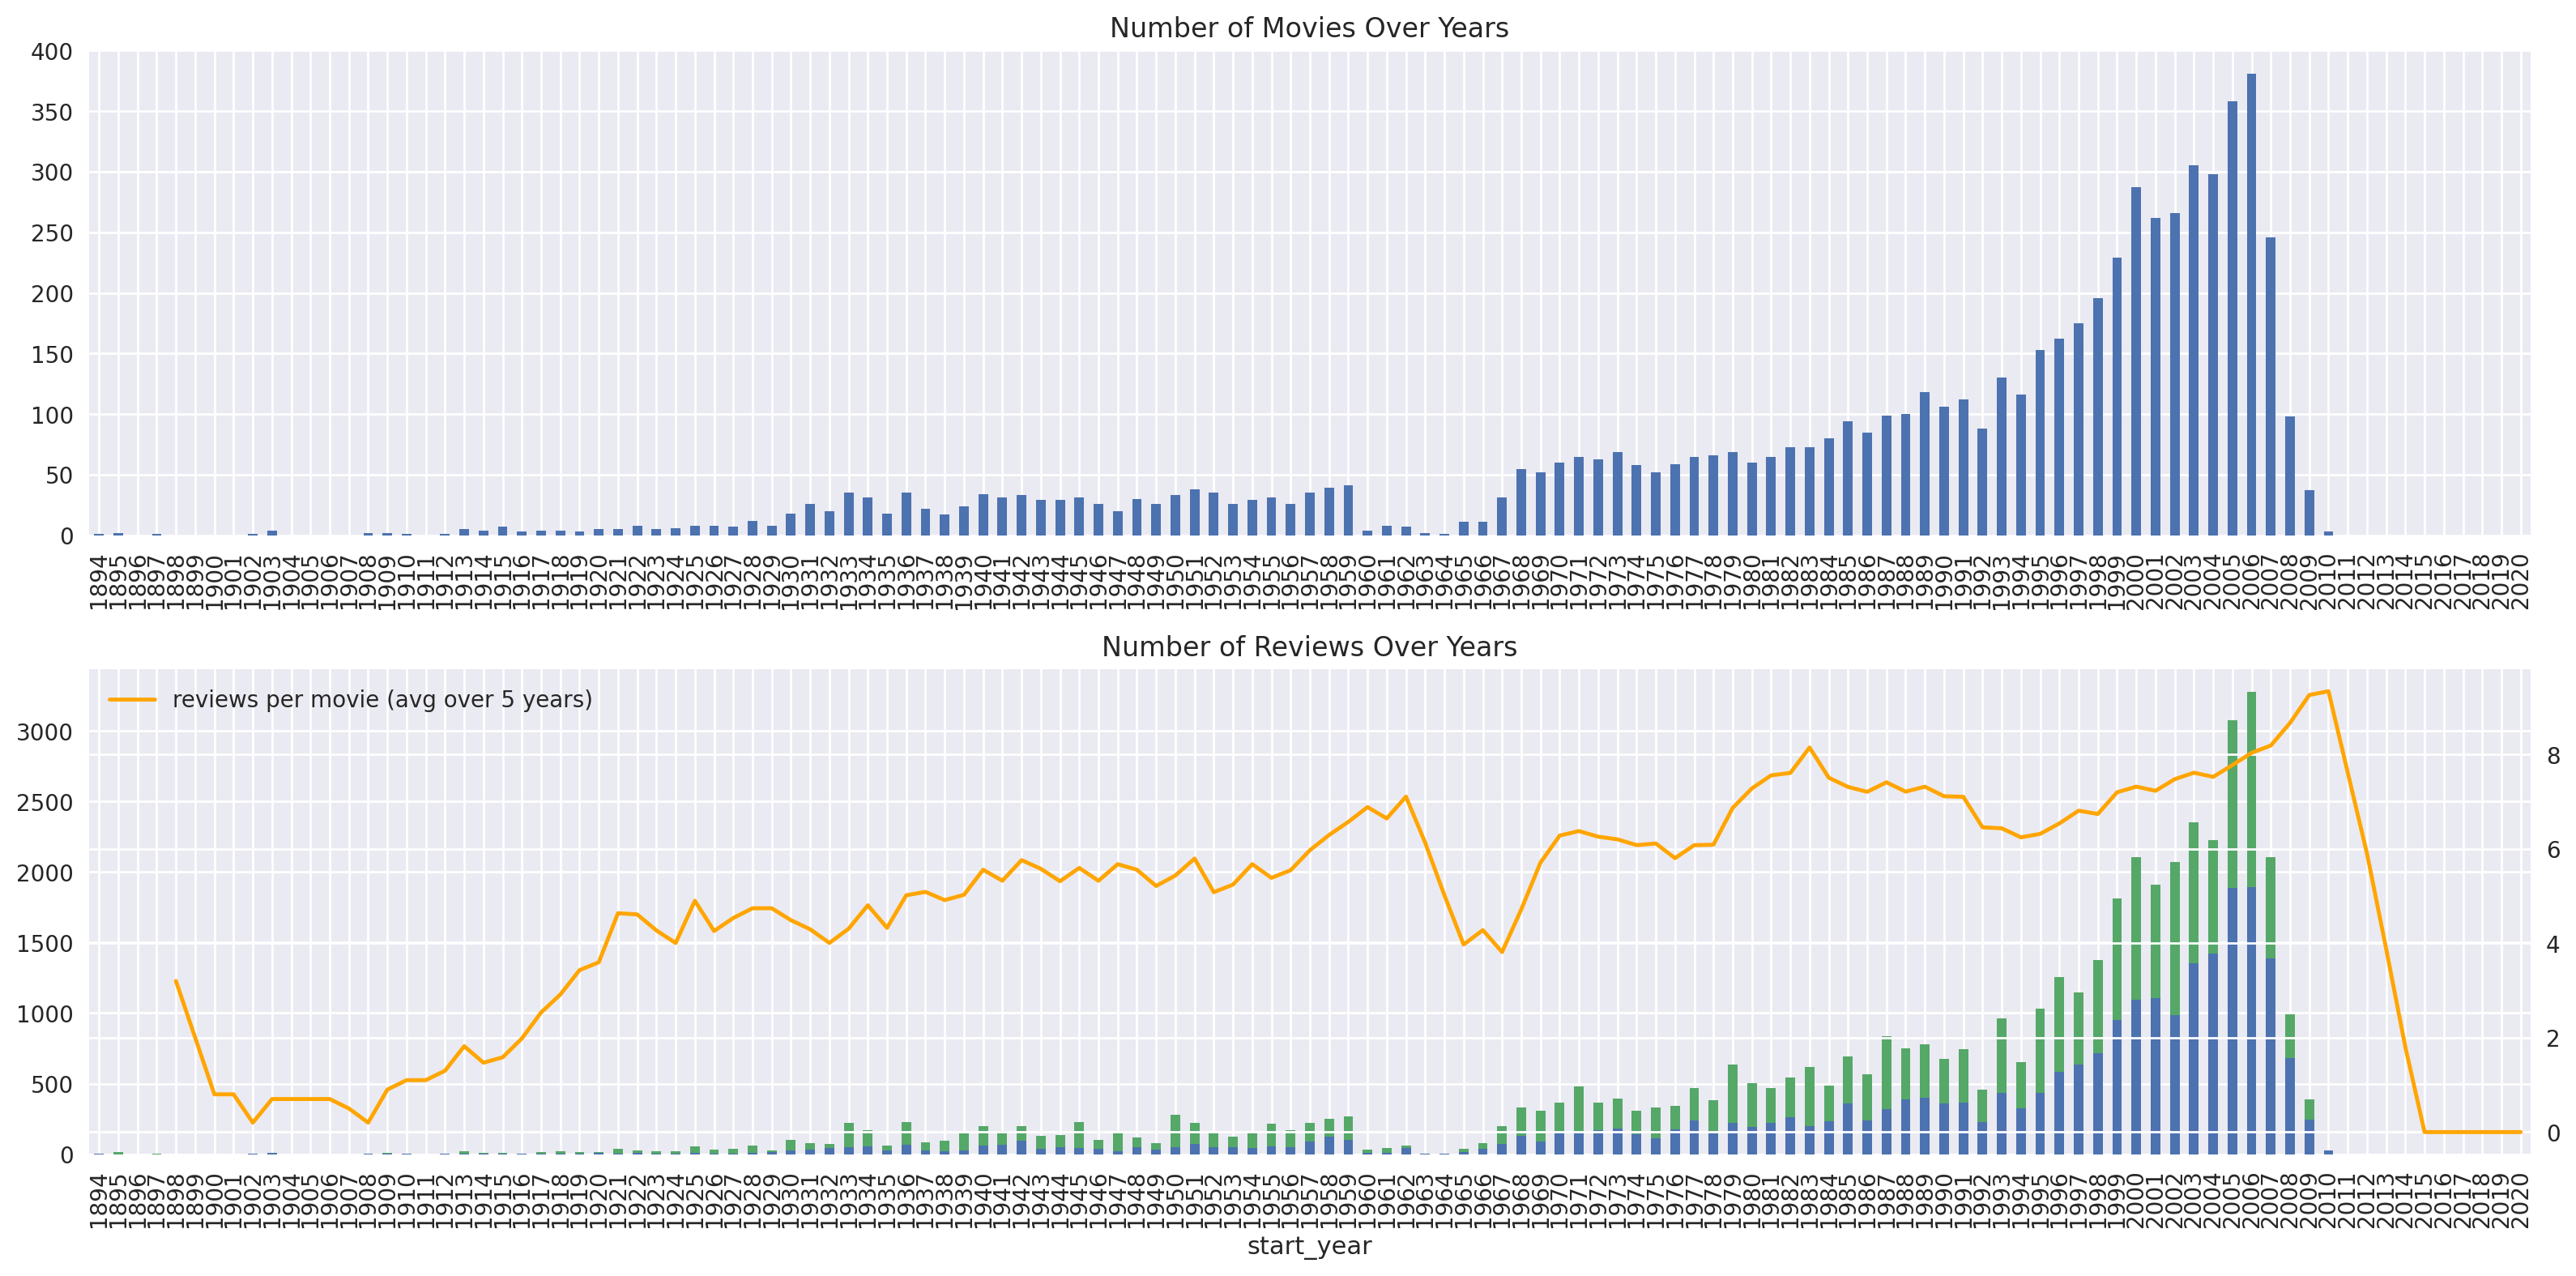

In [ ]:

fig, axs = plt.subplots(2, 1, figsize=(16, 8))


ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
print(dft1)

dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')





ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()


dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)




dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)





dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()







Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

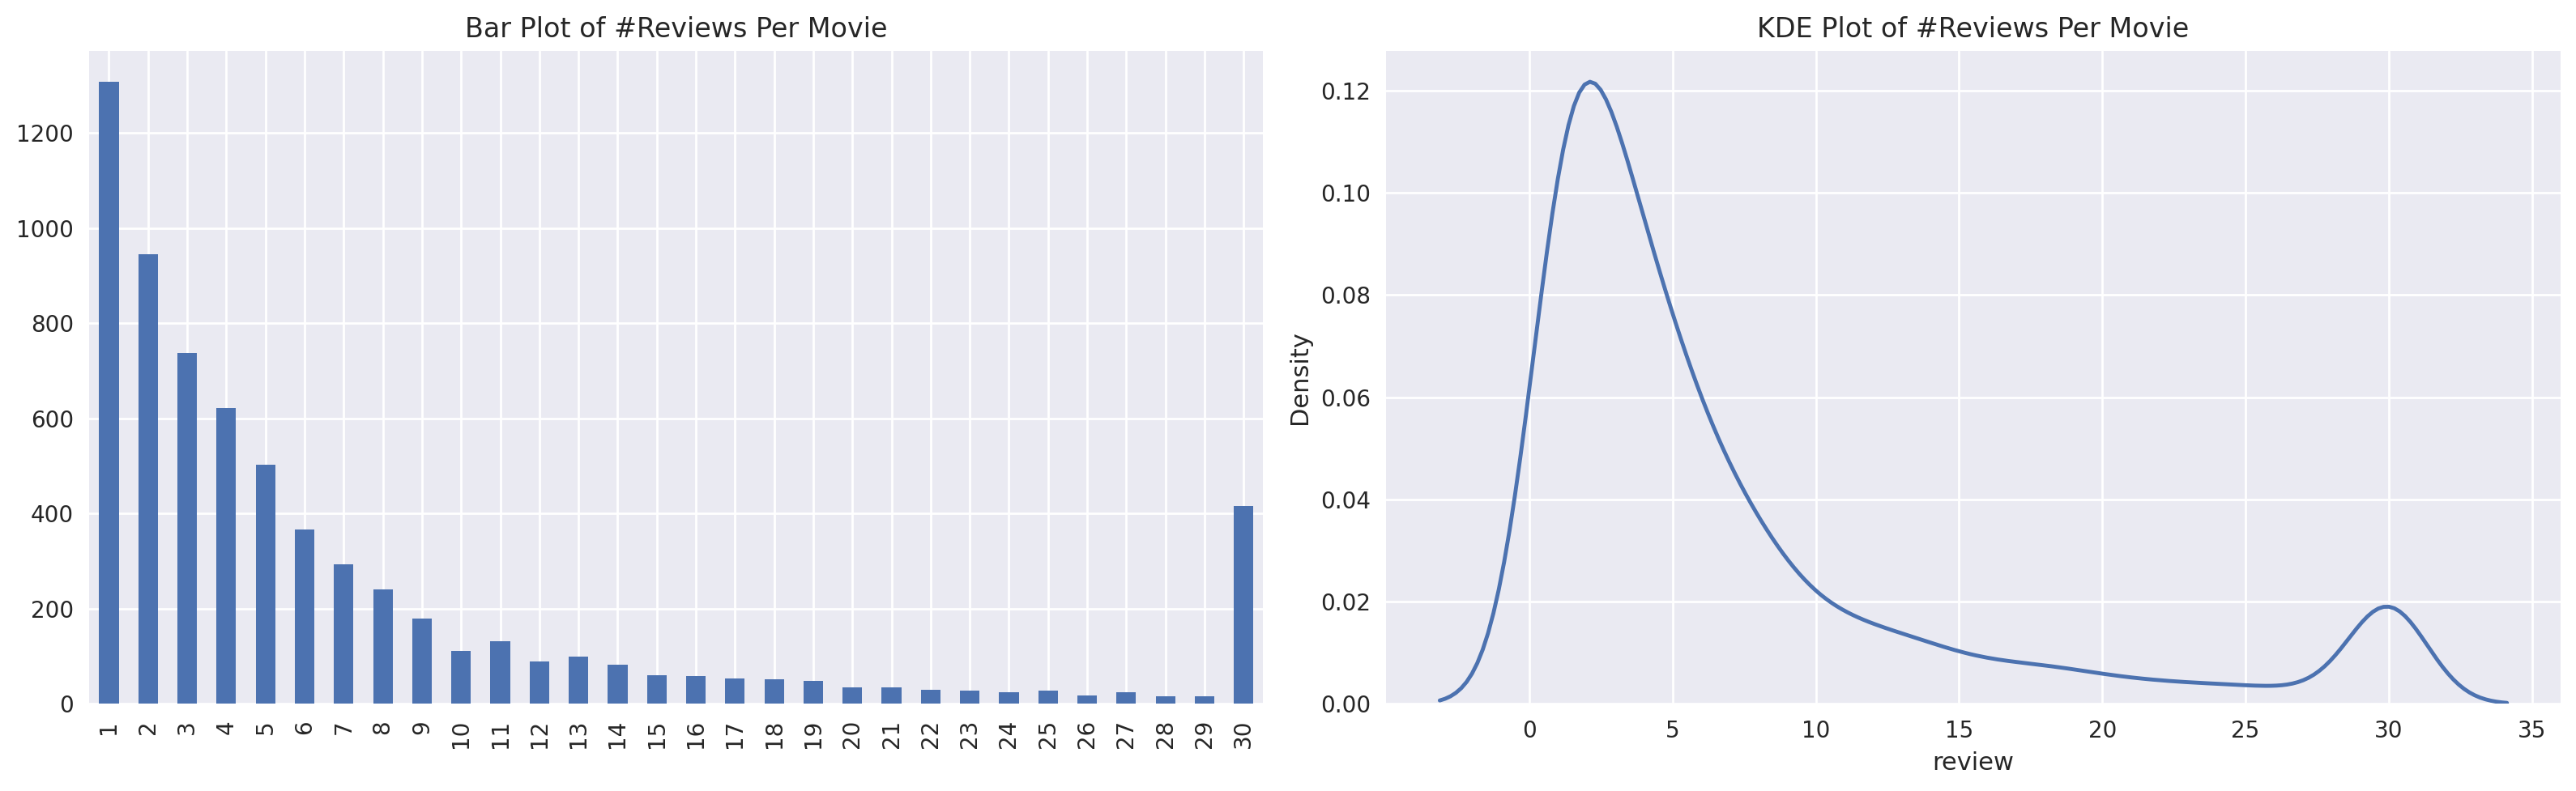

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
# print(dft)

dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()


In [ ]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

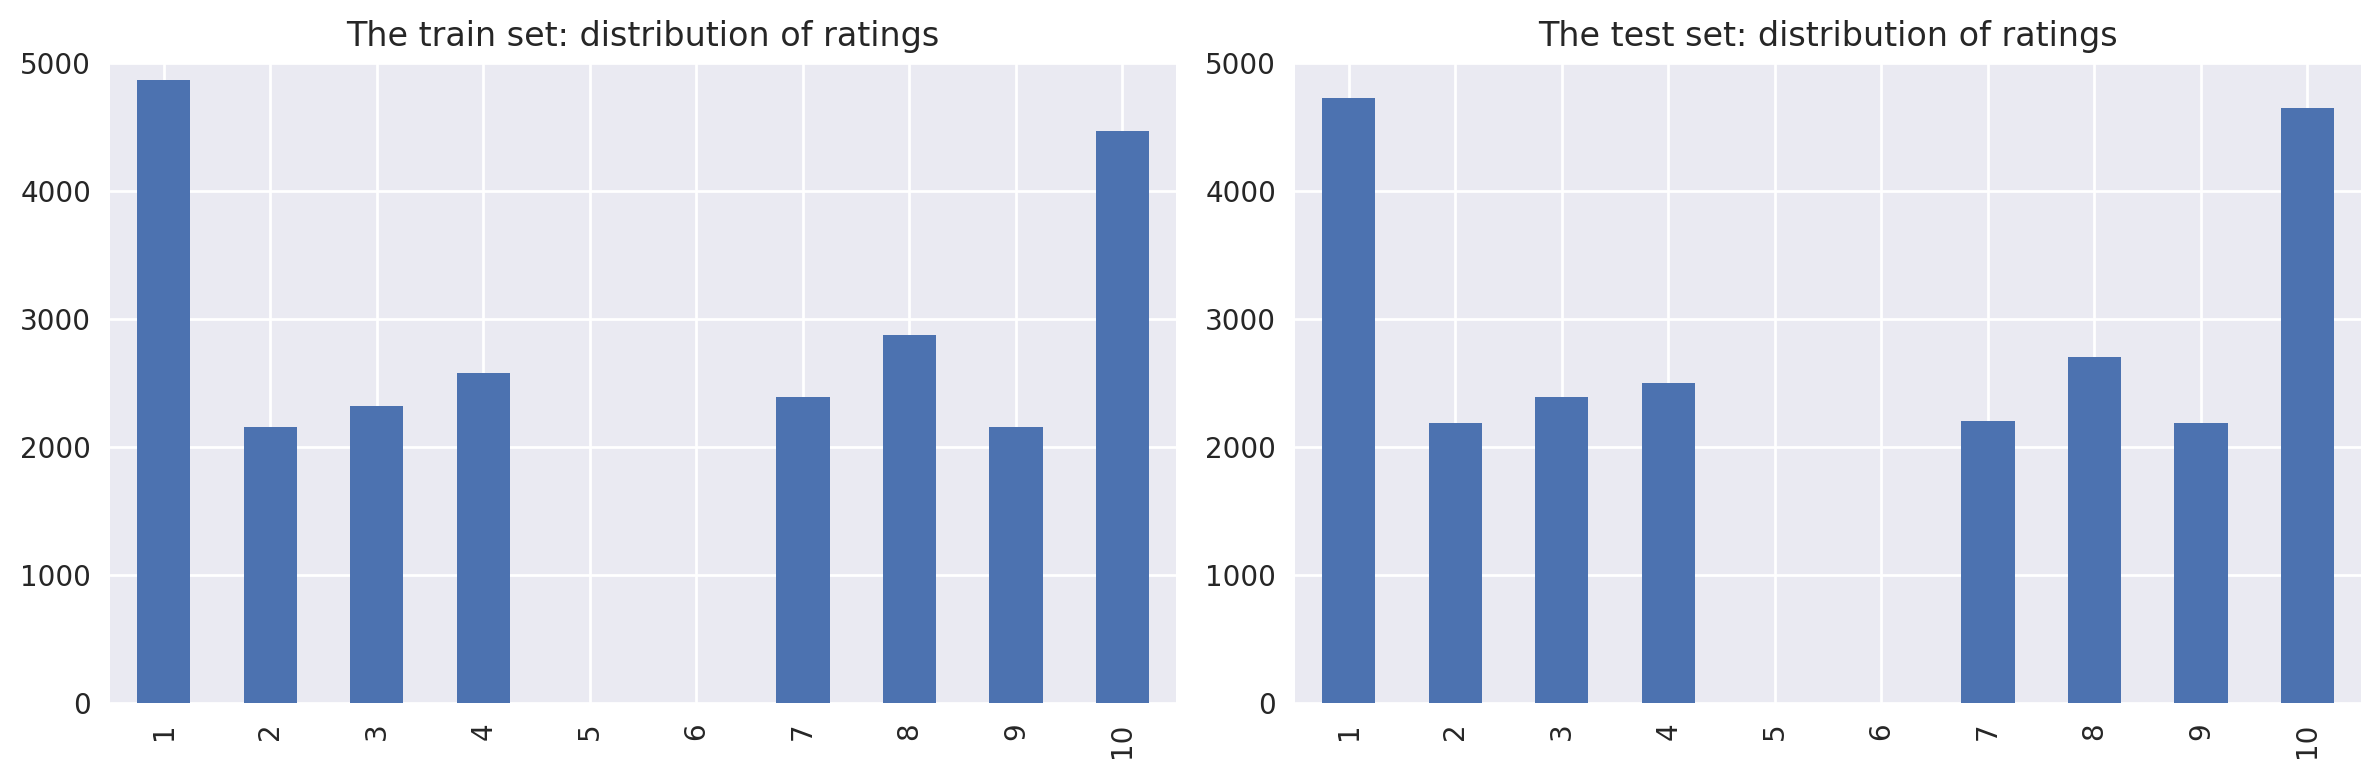

In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()


Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


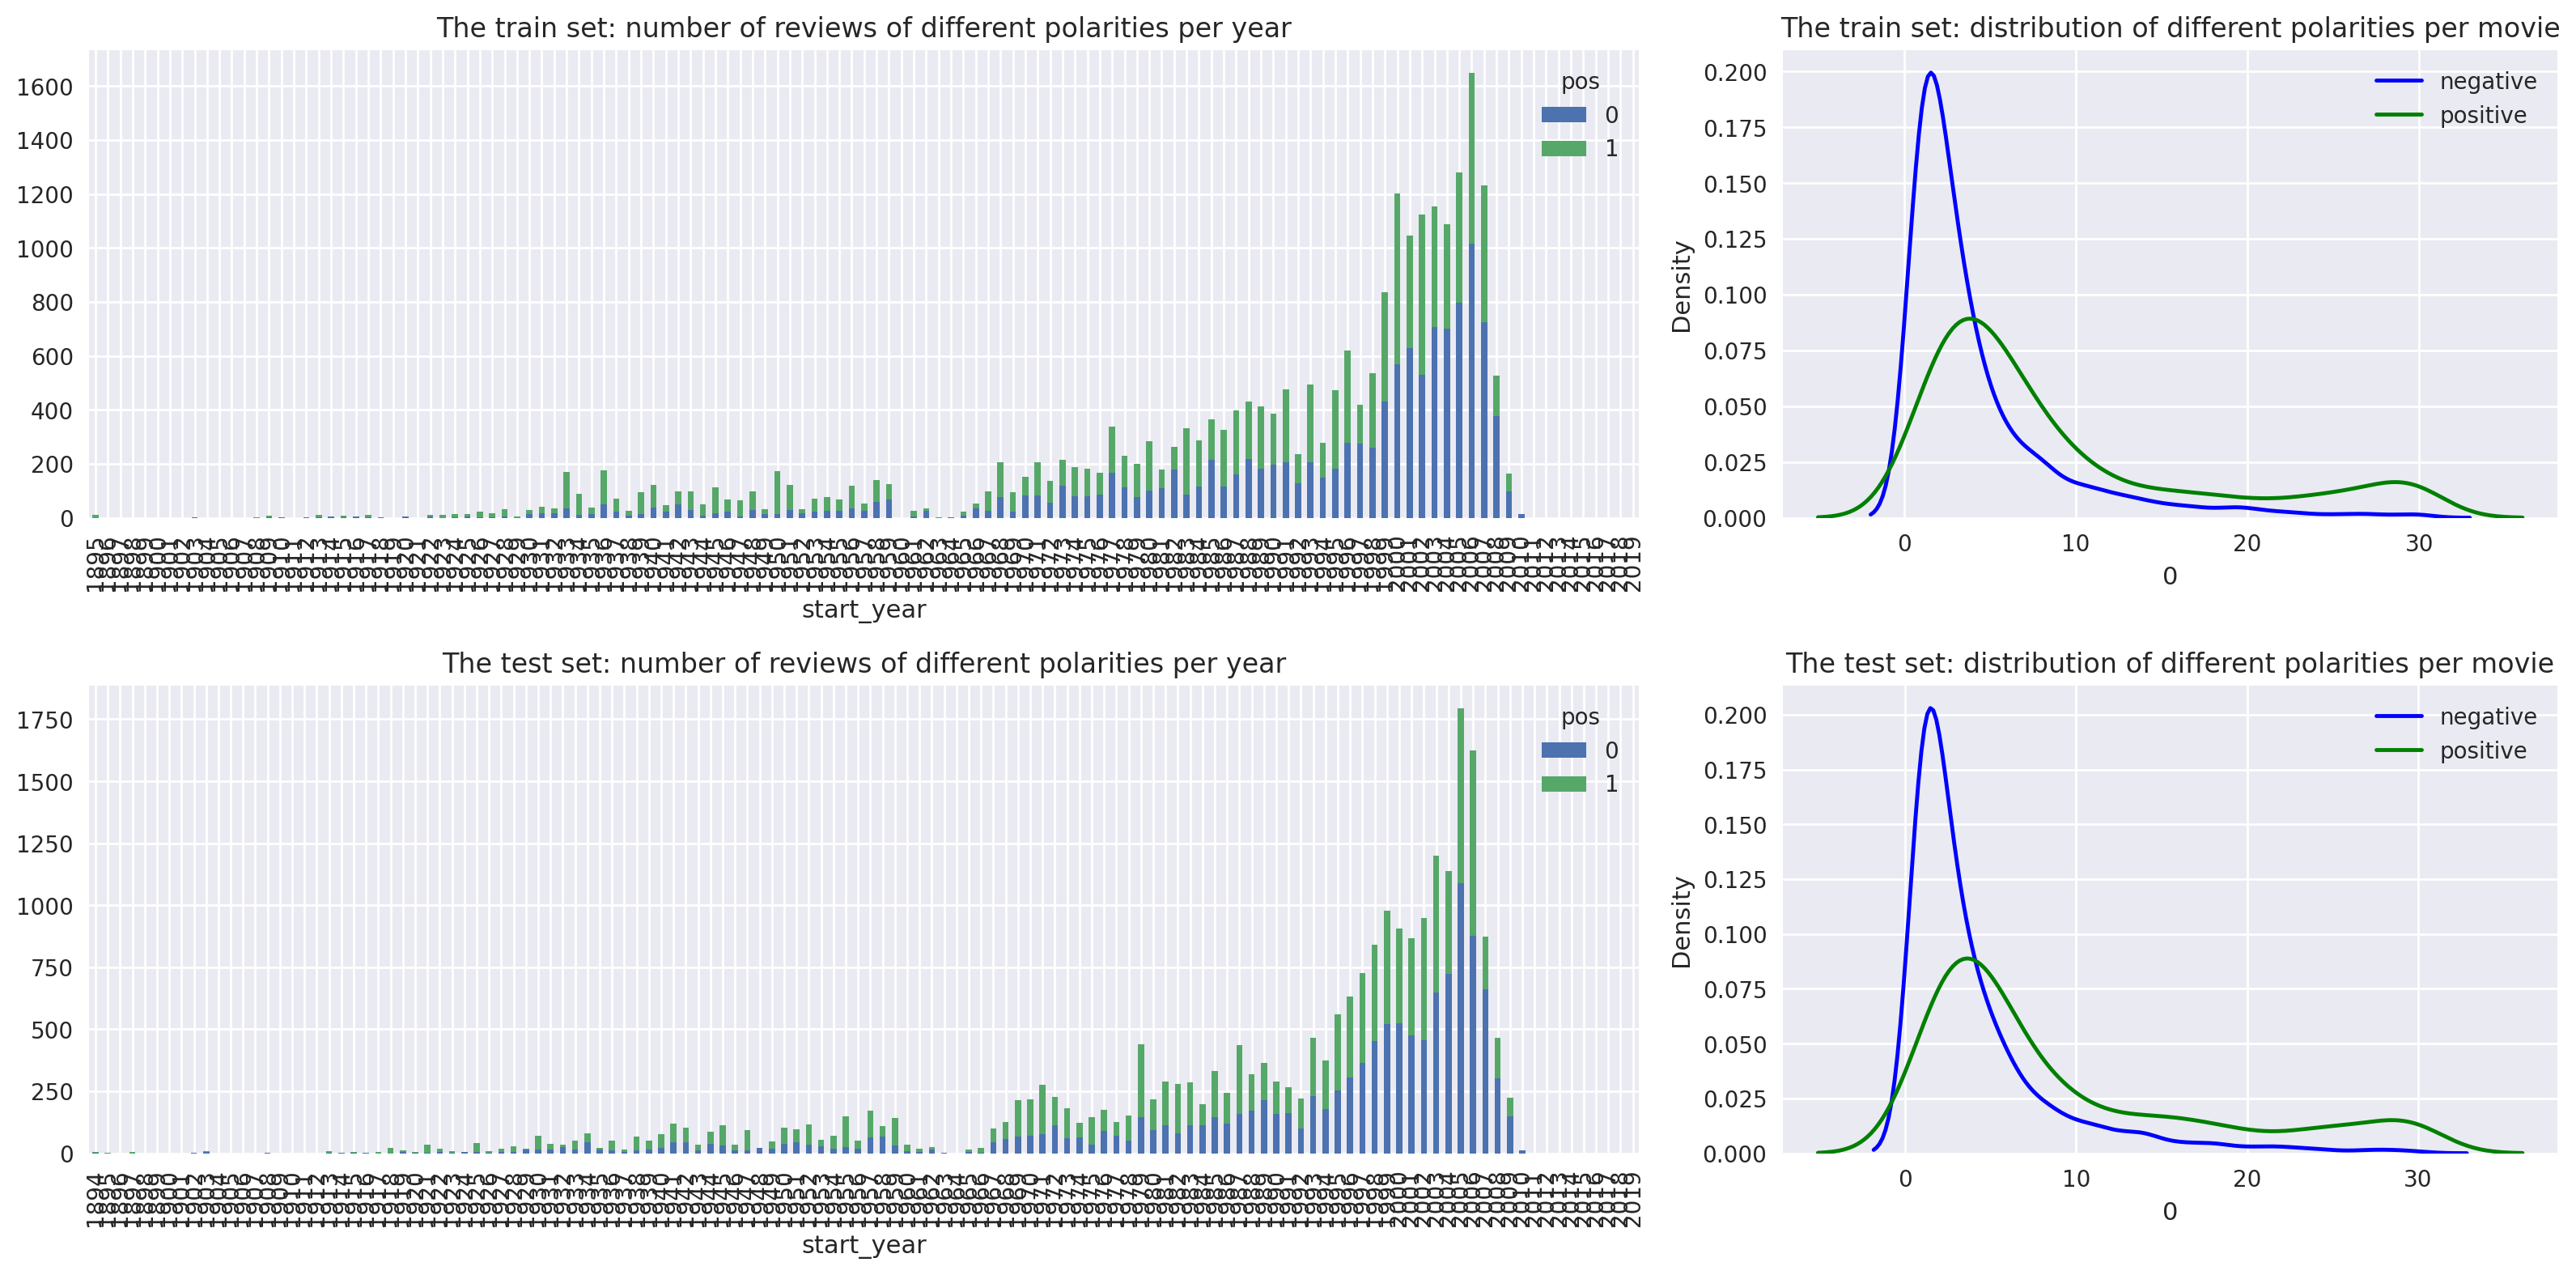

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()


## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [ ]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

In [ ]:
def clear_text(text):
    pattern = r"[^a-zA-Z']"
    text = text.lower()
    text = re.sub(pattern, " ", text)
    text = text.split()
    text = " ".join(text)
    return text


# def preprocess(text):
#     text = clear_text(text)
#     doc = nlp(text)
#     lemmas = [token.lemma_ for token in doc]
#     return " ".join(lemmas) 
  



We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [ ]:
# print(df_reviews)
df_reviews['review_clean'] = df_reviews['review'].apply(clear_text)


In [ ]:
print(df_reviews.head())

      tconst title_type primary_title original_title  start_year end_year  \
0  tt0068152      movie             $              $        1971       \N   
1  tt0068152      movie             $              $        1971       \N   
2  tt0313150      short          '15'           '15'        2002       \N   
3  tt0313150      short          '15'           '15'        2002       \N   
4  tt0313150      short          '15'           '15'        2002       \N   

  runtime_minutes  is_adult              genres  average_rating  votes  \
0             121         0  Comedy,Crime,Drama             6.3   2218   
1             121         0  Comedy,Crime,Drama             6.3   2218   
2              25         0  Comedy,Drama,Short             6.3    184   
3              25         0  Comedy,Drama,Short             6.3    184   
4              25         0  Comedy,Drama,Short             6.3    184   

                                              review  rating   sp  pos  \
0  The pakage impl

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [ ]:

df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']


# print(df_reviews_train.shape)
# print(df_reviews_test.shape)


train_features = df_reviews_train['review_clean']  # Use cleaned text
test_features = df_reviews_test['review_clean']
  


## Working with models

### Dummy model

In [ ]:
from sklearn.dummy import DummyClassifier

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


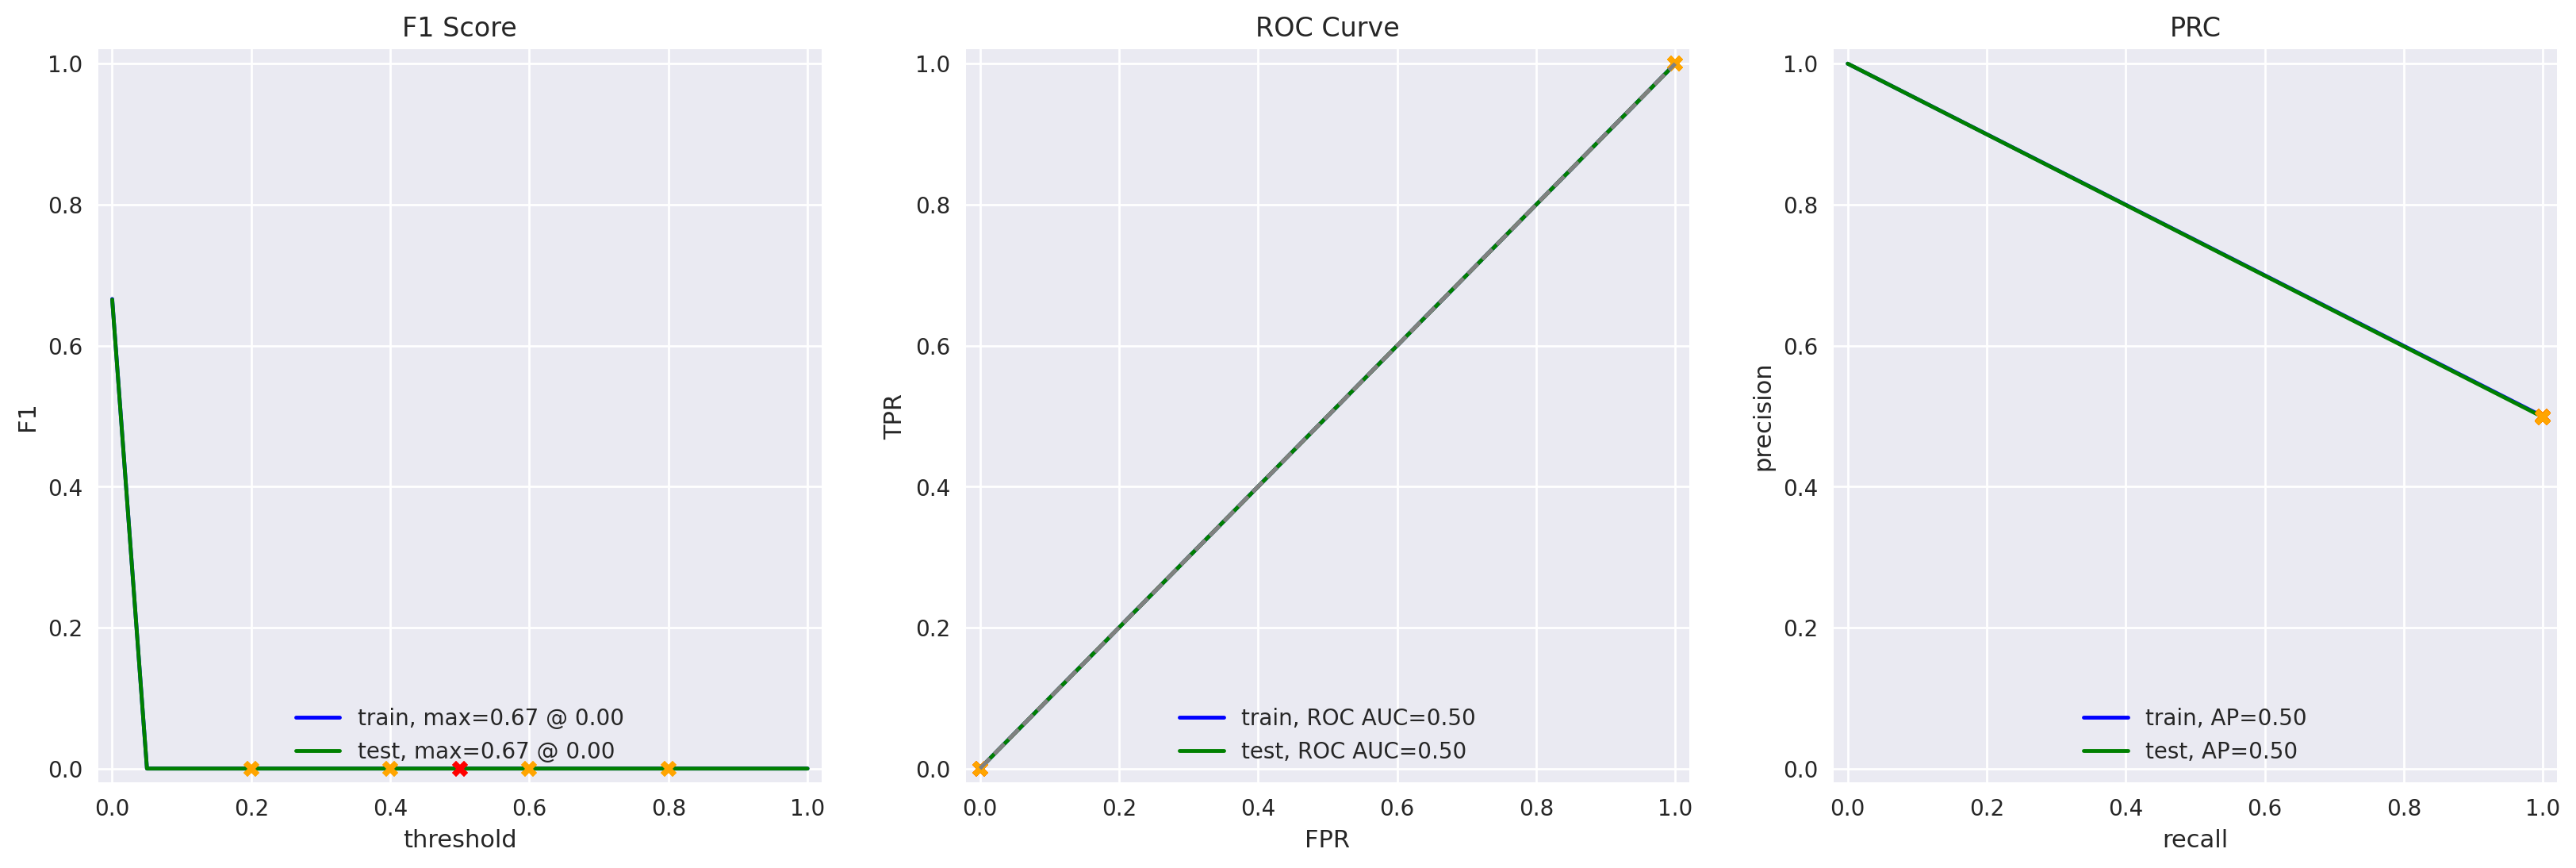

In [ ]:

dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(train_features, train_target)  # It ignores the features anyway
evaluate_model(dummy_model, train_features, train_target, test_features, test_target)


<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good first approach with the `Dummy` model.

</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Instead of `strategy='most_frequent'` you could use `strategy='constant', constant=1`, that is, replace `dummy_model = DummyClassifier(strategy = 'most_frequent', random_state=42)` by `dummy_model = DummyClassifier(strategy='constant', constant=1)`, the `F1` score with this should be 0.67 approximately. This is because we want a "real" dummy model that always predicts "1" regardless of the dataframe.

</div>

###  NLTK, TF-IDF and LR

TF-IDF

In [ ]:


import nltk
from nltk.corpus import stopwords as nltk_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords
stop_words = set(nltk_stopwords.words('english'))
count_tf_idf_lr = TfidfVectorizer(stop_words=stop_words)





In [ ]:


tf_idf_train_features = df_reviews_train['review_clean']  # Use cleaned text
tf_idf_test_features = df_reviews_test['review_clean']
tf_idf_train = count_tf_idf_lr.fit_transform(tf_idf_train_features)
tf_idf_test = count_tf_idf_lr.transform(tf_idf_test_features)  # Just transform, no fit!
logistic_regression = LogisticRegression(solver= 'liblinear', random_state = 1234)
logistic_regression.fit(tf_idf_train, train_target)
predictions = logistic_regression.predict(tf_idf_test)



          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


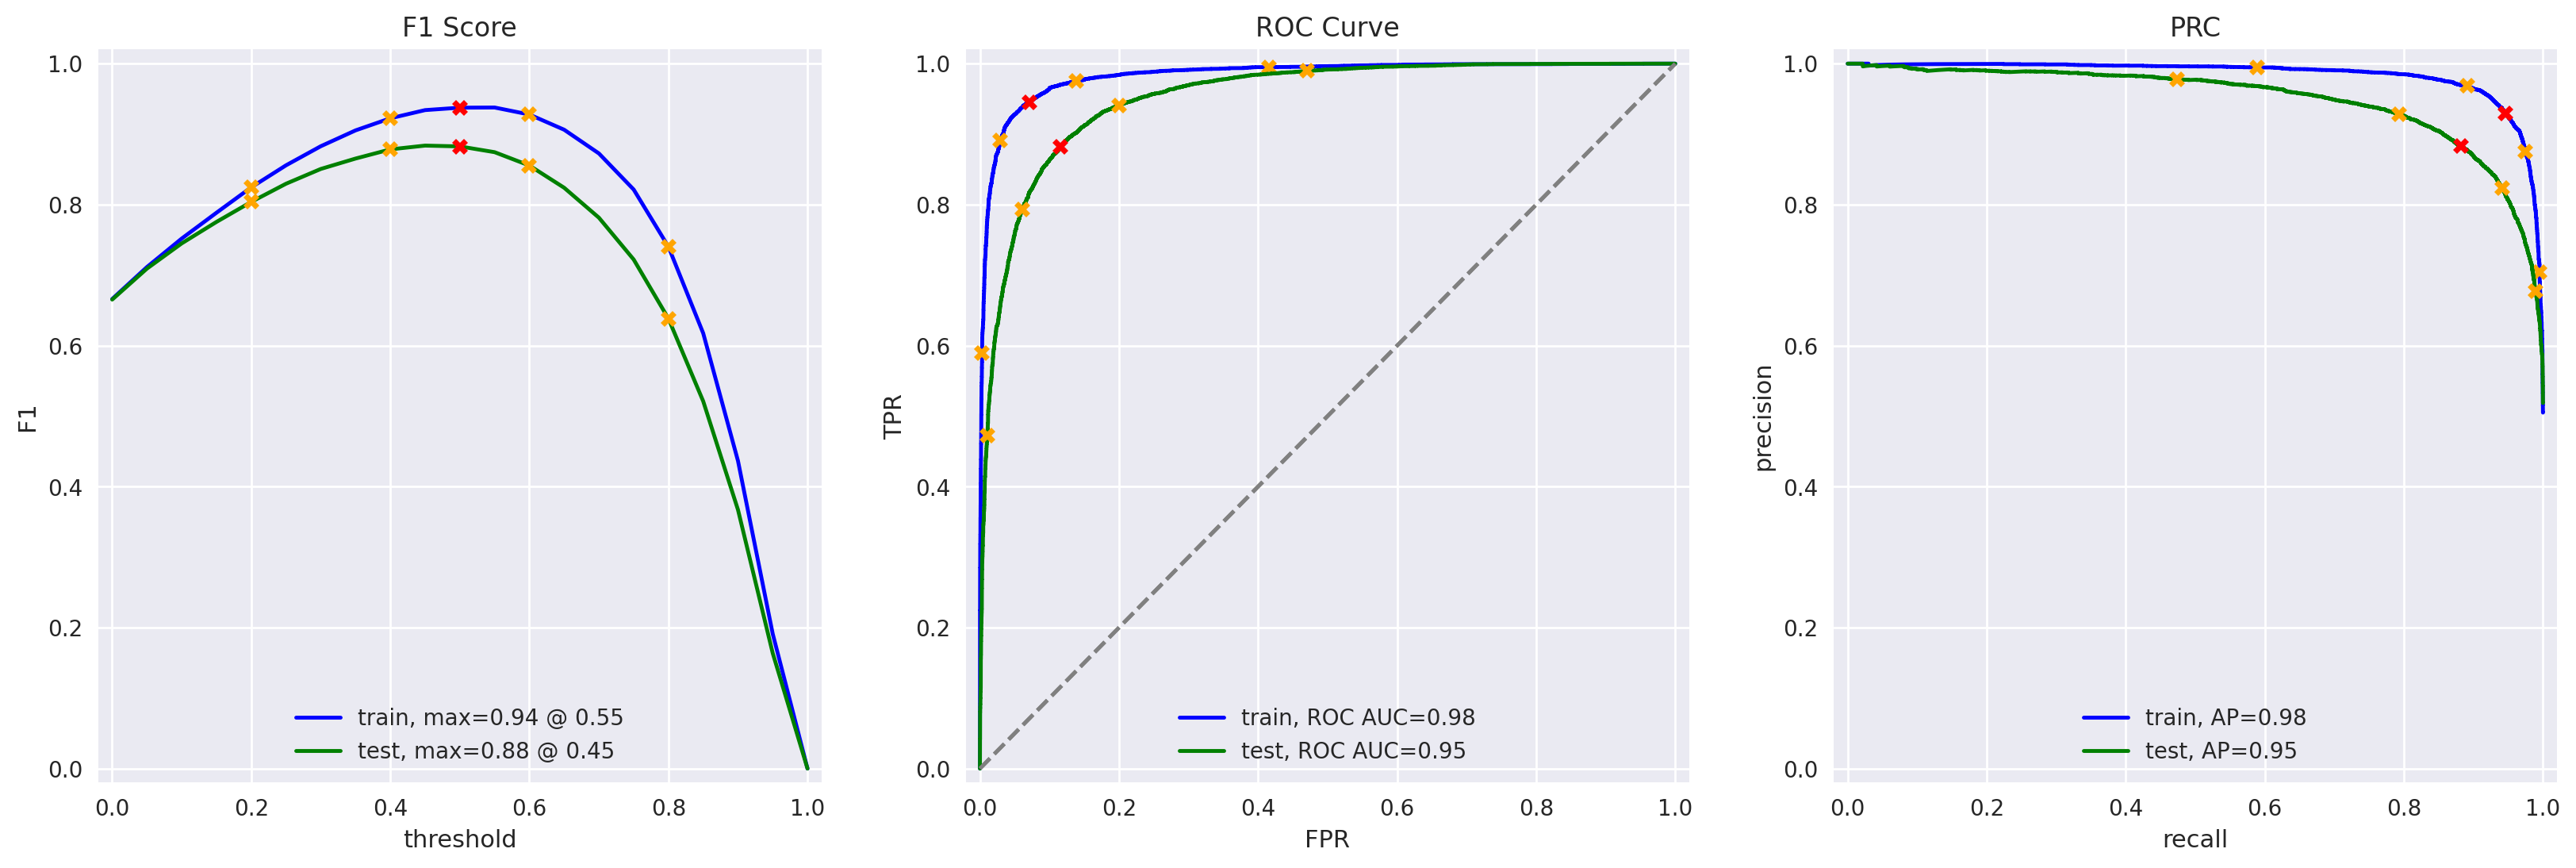

In [ ]:
evaluate_model(logistic_regression, tf_idf_train, train_target, tf_idf_test, test_target)

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good job with this model.

</div>

### spaCy, TF-IDF and LR

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [ ]:
def preprocess_spacy(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [ ]:
df_reviews_train['review_spacy'] = df_reviews_train['review'].apply(preprocess_spacy)
df_reviews_test['review_spacy'] = df_reviews_test['review'].apply(preprocess_spacy)

In [ ]:
count_tf_idf_lr_spacy = TfidfVectorizer()
tf_idf_train = count_tf_idf_lr_spacy.fit_transform(df_reviews_train['review_spacy'])
tf_idf_test = count_tf_idf_lr_spacy.transform(df_reviews_test['review_spacy'])

logistic_regression_spacy = LogisticRegression(solver= 'liblinear', random_state = 1234)
logistic_regression_spacy.fit(tf_idf_train, train_target)
predictions = logistic_regression_spacy.predict(tf_idf_test)

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


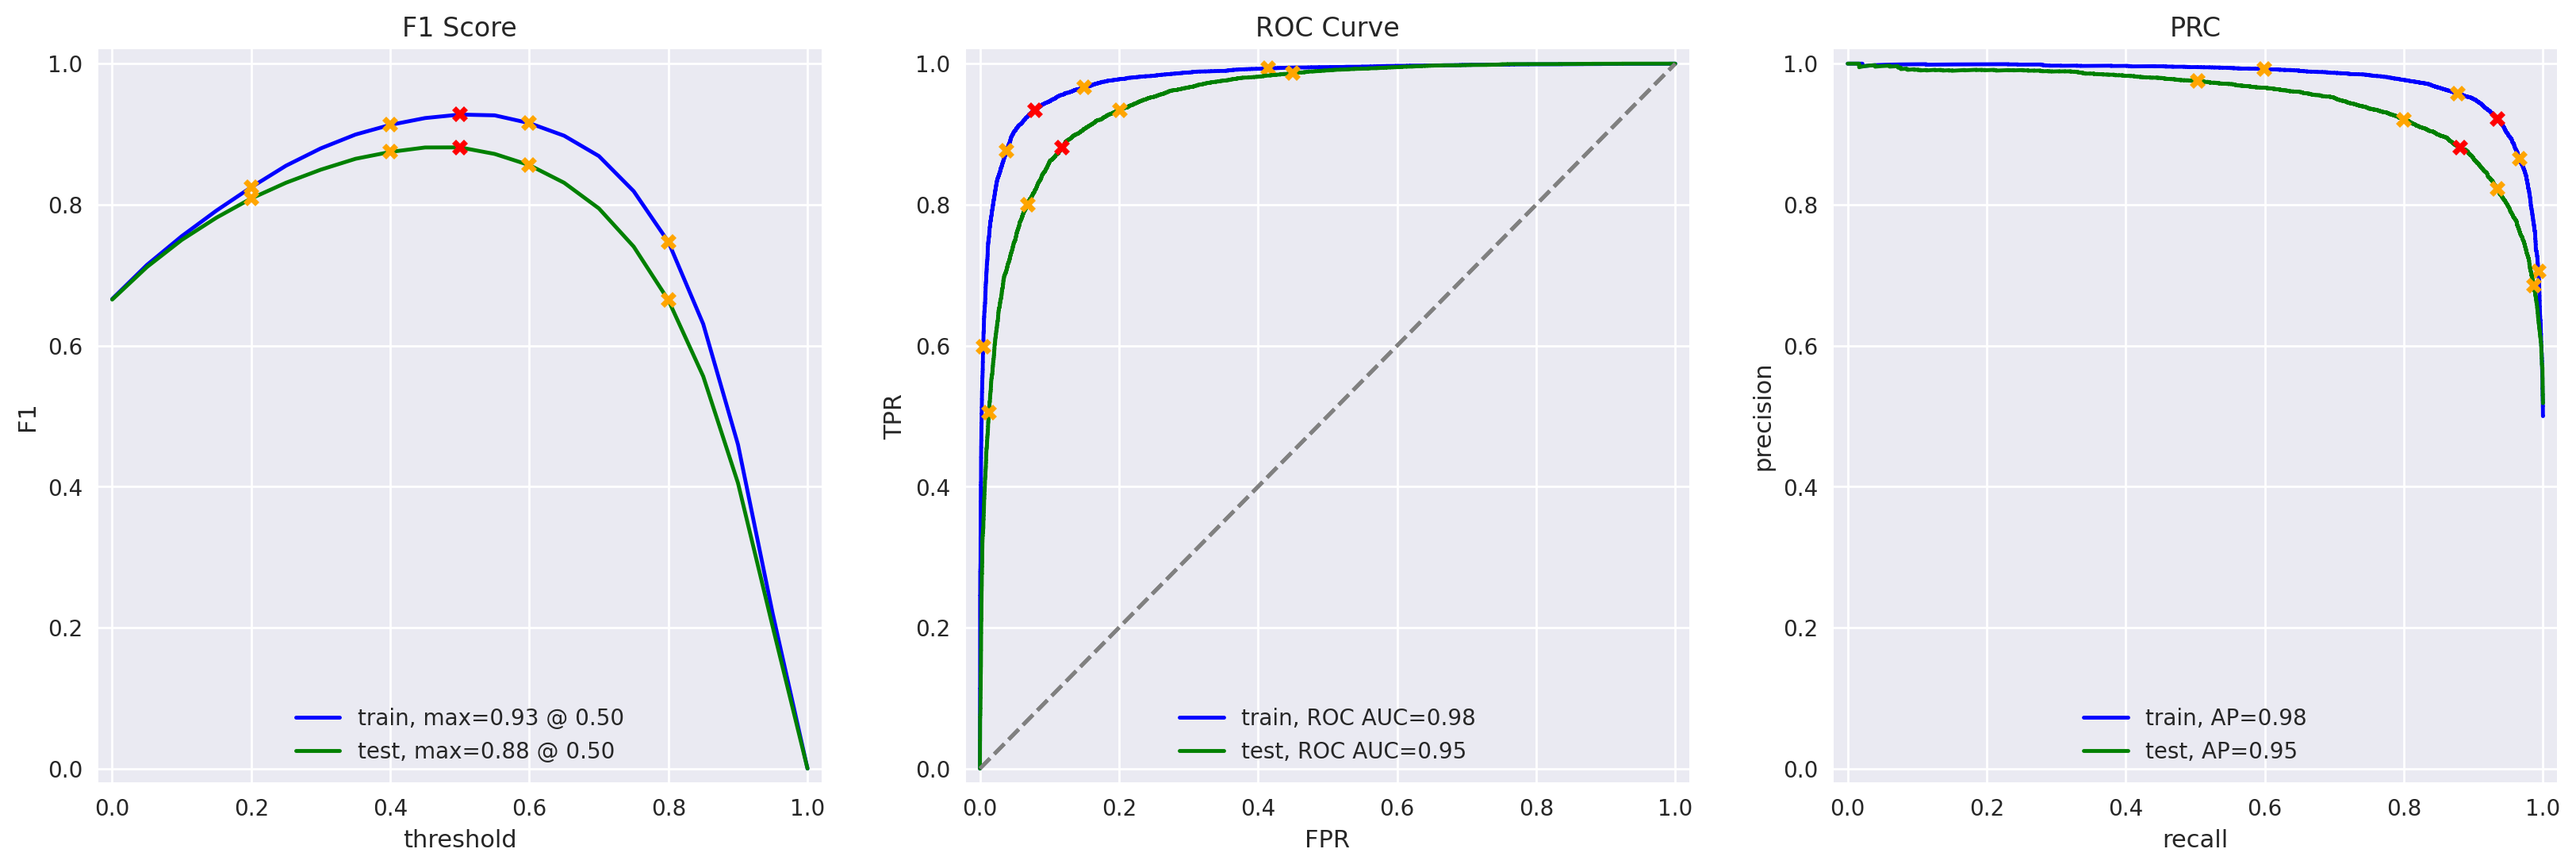

In [ ]:
evaluate_model(logistic_regression_spacy, tf_idf_train, train_target, tf_idf_test, test_target)

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good job with this `spaCy, TF-IDF and LR` model.

</div>

### spaCy, TF-IDF and LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
LGBM_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=1234
)

          train  test
Accuracy   0.97  0.87
F1         0.97  0.87
APS        0.99  0.94
ROC AUC    0.99  0.95


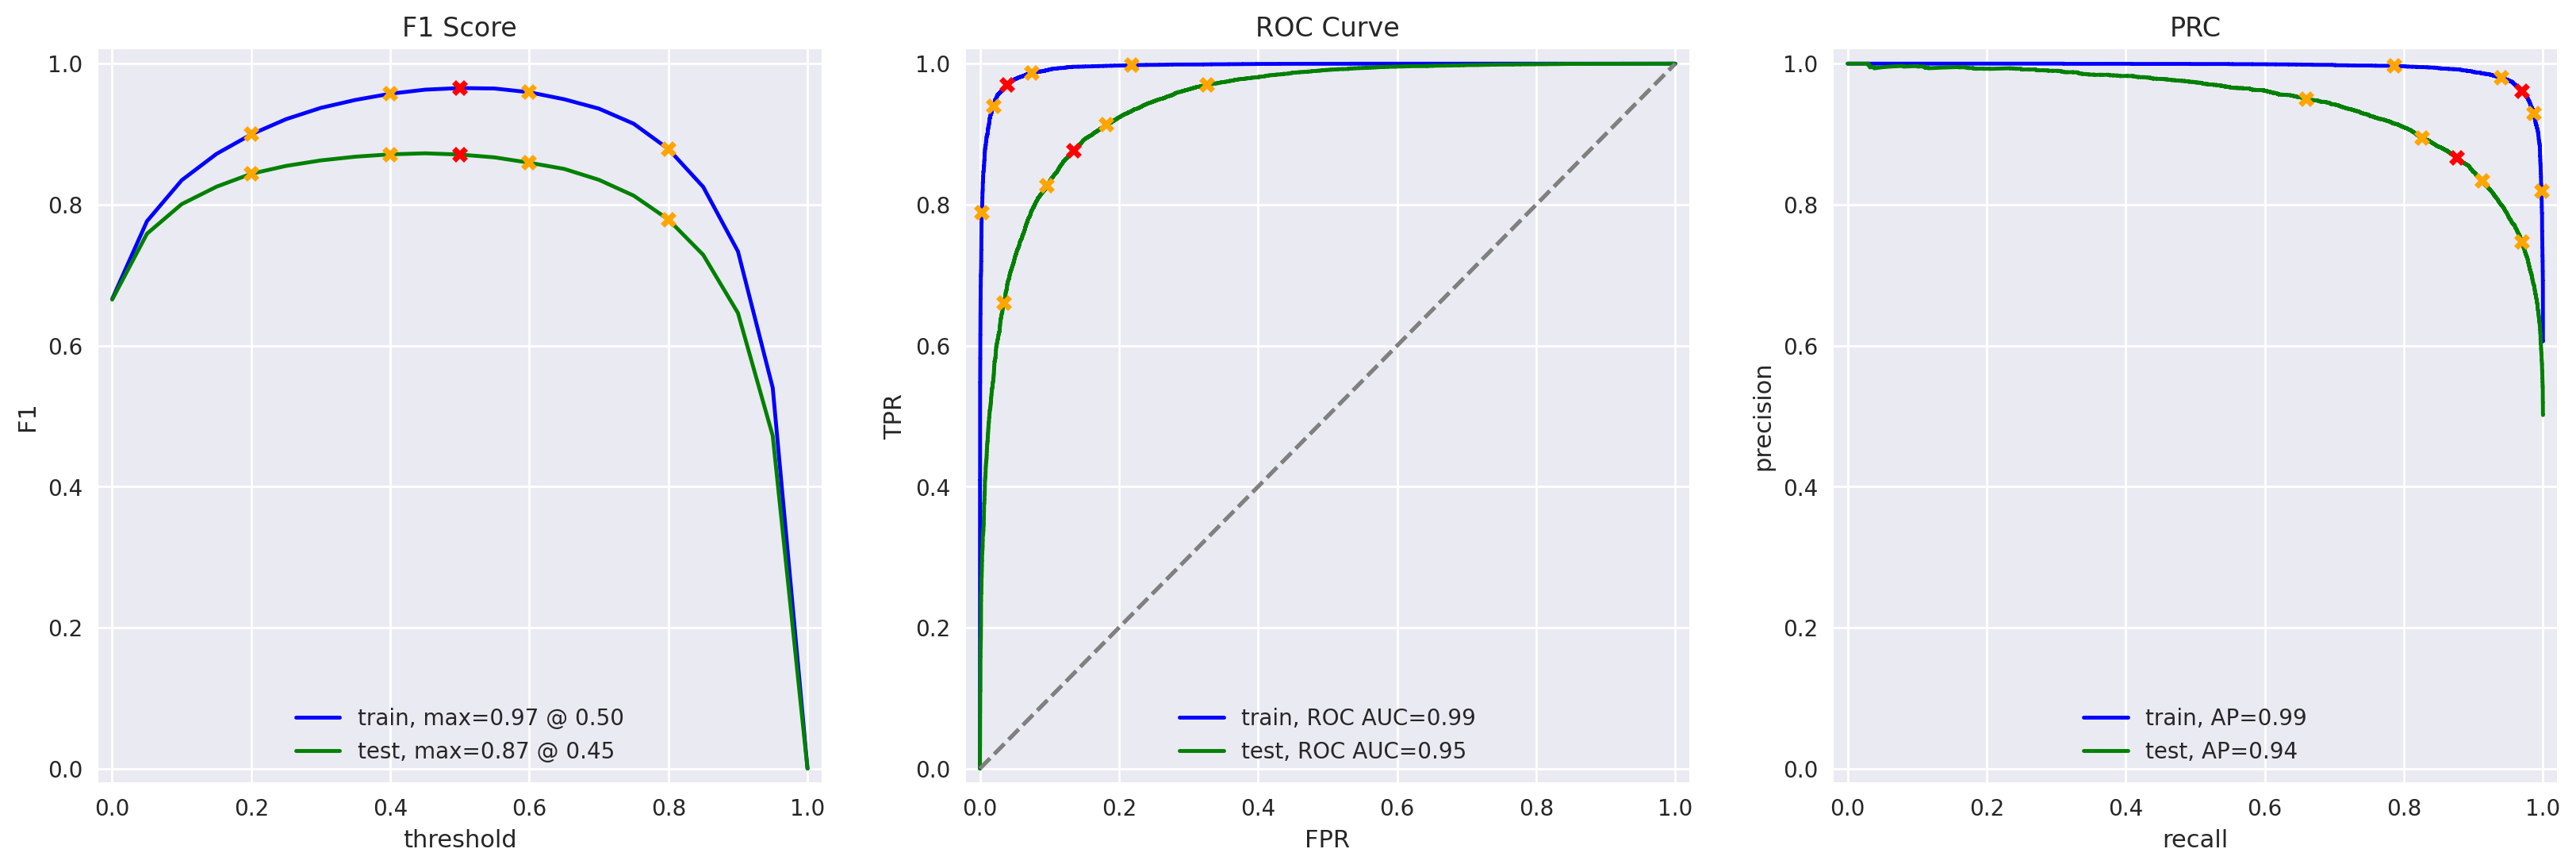

In [ ]:
LGBM_model.fit(tf_idf_train, train_target)
predictions = LGBM_model.predict(tf_idf_test)
evaluate_model(LGBM_model, tf_idf_train, train_target, tf_idf_test, test_target)

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good job with this `spaCy, TF-IDF and LGBMClassifier` model.

</div>

###  Model 9 - BERT

In [ ]:
# 
import torch
# import transformers


In [ ]:
# tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
# config = transformers.BertConfig.from_pretrained('bert-base-uncased')
# model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [ ]:
# def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
#     ids_list = []
#     attention_mask_list = []

#     # text to padded ids of tokens along with their attention masks
    
#     # <put your code here to create ids_list and attention_mask_list>
    
#     if force_device is not None:
#         device = torch.device(force_device)
#     else:
#         device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
#     model.to(device)
#     if not disable_progress_bar:
#         print(f'Using the {device} device.')
    
#     # gettings embeddings in batches

#     embeddings = []

#     for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
#         ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
#         # <put your code here to create attention_mask_batch
            
#         with torch.no_grad():            
#             model.eval()
#             batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
#         embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
#     return np.concatenate(embeddings)

In [ ]:
# Attention! Running BERT for thousands of texts may take long run on CPU, at least several hours
# train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

In [ ]:
# 
# print(df_reviews_train['review_norm'].shape)
# # print(train_features_9.shape)
# # print(train_target.shape)


In [ ]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## My Reviews

In [ ]:


# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples



my_reviews = pd.DataFrame([
    'This movie was absolutely terrible from start to finish.',
'I loved every minute of this incredible film.',
'The plot was confusing and hard to follow.',
'Amazing cinematography and brilliant acting throughout.',
'Boring and predictable, I almost fell asleep.',
'One of the best movies I have seen this year.',
'The dialogue felt forced and unnatural.',
'Fantastic special effects and great soundtrack.',
'Waste of time, would not recommend to anyone.',
'Beautifully crafted story with emotional depth.',
'The ending was disappointing and made no sense.',
'Perfect blend of action and comedy, highly entertaining.',
'Poor character development and weak storyline.',
'Outstanding performance by the lead actor.',
'Too long and dragged on without purpose.',
'Masterpiece of modern cinema, absolutely brilliant.',
'Terrible acting and cheap production values.',
'Heartwarming story that made me cry.',
'Completely overrated, don\'t understand the hype.',
'Incredible movie that exceeded all my expectations.',

# --- Sarcasm / tricky ---
'Wow, what a masterpiece… I’ve never been so bored in my life.',
'Absolutely amazing… if your goal is to fall asleep quickly.',
'Best movie ever, I regret watching every second of it.',
'Incredible work, truly impressive how bad it turned out.',
'Yeah, because that plot totally made sense… not.',
'Loved it… said no one in the theater.',
'An unforgettable experience, unfortunately for all the wrong reasons.',
'Brilliant… just brilliantly awful.',
'Two hours of pure joy… if you enjoy suffering.',
'What a great film, I almost walked out twice.',

# --- Mixed sentiment ---
'Great acting, but the story was painfully dull.',
'The visuals were stunning, although everything else fell flat.',
'I liked the concept, but the execution ruined it.',
'Strong beginning, disappointing ending.',
'Some scenes were fantastic, others were hard to watch.',
'It had potential, but didn’t quite deliver.',
'Enjoyable at times, but overall forgettable.',
'Not bad, but definitely not great either.',
'I expected more, though it had a few good moments.',
'Decent movie with some obvious flaws.',

# --- Subtle / misleading ---
'I’ve seen worse movies, I guess.',
'It tries really hard to be good.',
'That was certainly a movie.',
'I didn’t hate it.',
'I’m not saying it was bad… but it wasn’t good either.',
'It exists, that’s for sure.',
'Well, that happened.',
'I suppose some people might enjoy this.',
'It’s not the worst thing I’ve watched.',
'Interesting choices were made.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(clear_text)
print("New reviews created!")
print(my_reviews.head())




New reviews created!
                                              review  \
0  This movie was absolutely terrible from start ...   
1      I loved every minute of this incredible film.   
2         The plot was confusing and hard to follow.   
3  Amazing cinematography and brilliant acting th...   
4      Boring and predictable, I almost fell asleep.   

                                         review_norm  
0  this movie was absolutely terrible from start ...  
1       i loved every minute of this incredible film  
2          the plot was confusing and hard to follow  
3  amazing cinematography and brilliant acting th...  
4        boring and predictable i almost fell asleep  


<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Great job creating the `my_reviews` dataframe.

</div>

###  NLTK, TF-IDF and LR

In [ ]:

texts = my_reviews['review_norm']

my_reviews_pred_prob = logistic_regression.predict_proba(count_tf_idf_lr.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')




0.06:  this movie was absolutely terrible from start to finish
0.94:  i loved every minute of this incredible film
0.15:  the plot was confusing and hard to follow
0.97:  amazing cinematography and brilliant acting throughout
0.01:  boring and predictable i almost fell asleep
0.96:  one of the best movies i have seen this year
0.18:  the dialogue felt forced and unnatural
0.99:  fantastic special effects and great soundtrack
0.04:  waste of time would not recommend to anyone
0.90:  beautifully crafted story with emotional depth
0.05:  the ending was disappointing and made no sense
0.99:  perfect blend of action and comedy highly entertaining
0.01:  poor character development and weak storyline
0.74:  outstanding performance by the lead actor
0.44:  too long and dragged on without purpose
0.95:  masterpiece of modern cinema absolutely brilliant
0.02:  terrible acting and cheap production values
0.73:  heartwarming story that made me cry
0.17:  completely overrated don't understand the h

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good job testing this model with the `my_reviews` dataframe.

</div>

### spaCy, TF-IDF and LR

In [ ]:

texts = my_reviews['review_norm']

my_reviews_pred_prob = logistic_regression_spacy.predict_proba(
    count_tf_idf_lr_spacy.transform(texts.apply(lambda x: preprocess_spacy(x)))
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


0.03:  this movie was absolutely terrible from start to finish
0.80:  i loved every minute of this incredible film
0.19:  the plot was confusing and hard to follow
0.97:  amazing cinematography and brilliant acting throughout
0.01:  boring and predictable i almost fell asleep
0.96:  one of the best movies i have seen this year
0.34:  the dialogue felt forced and unnatural
0.99:  fantastic special effects and great soundtrack
0.03:  waste of time would not recommend to anyone
0.87:  beautifully crafted story with emotional depth
0.03:  the ending was disappointing and made no sense
0.99:  perfect blend of action and comedy highly entertaining
0.01:  poor character development and weak storyline
0.82:  outstanding performance by the lead actor
0.33:  too long and dragged on without purpose
0.94:  masterpiece of modern cinema absolutely brilliant
0.01:  terrible acting and cheap production values
0.67:  heartwarming story that made me cry
0.12:  completely overrated don't understand the h

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good job testing this model with the `my_reviews` dataframe.

</div>

### spaCy, TF-IDF and LGBMClassifier

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = LGBM_model.predict_proba(count_tf_idf_lr_spacy.transform(texts.apply(lambda x: preprocess_spacy(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.11:  this movie was absolutely terrible from start to finish
0.81:  i loved every minute of this incredible film
0.58:  the plot was confusing and hard to follow
0.95:  amazing cinematography and brilliant acting throughout
0.04:  boring and predictable i almost fell asleep
0.91:  one of the best movies i have seen this year
0.57:  the dialogue felt forced and unnatural
0.96:  fantastic special effects and great soundtrack
0.08:  waste of time would not recommend to anyone
0.79:  beautifully crafted story with emotional depth
0.15:  the ending was disappointing and made no sense
0.94:  perfect blend of action and comedy highly entertaining
0.04:  poor character development and weak storyline
0.74:  outstanding performance by the lead actor
0.44:  too long and dragged on without purpose
0.89:  masterpiece of modern cinema absolutely brilliant
0.07:  terrible acting and cheap production values
0.62:  heartwarming story that made me cry
0.18:  completely overrated don't understand the h

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good job testing this model with the `my_reviews` dataframe.

</div>

### Model 9

In [ ]:
# 
# texts = my_reviews['review_norm']


# my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)


# my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

# for i, review in enumerate(texts.str.slice(0, 100)):
#     print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


## Conclusions



- The dummy model performs at chance level (Accuracy = 0.5, F1 = 0), confirming it has no predictive power and serves only as a baseline.

- TF-IDF with Logistic Regression (both NLTK and spaCy preprocessing) achieved the best balance between performance and generalization, with a test F1 score of **0.88** and ROC AUC of **0.95**. The small gap between training and test performance indicates strong generalization.

- No significant difference was observed between NLTK and spaCy preprocessing, suggesting that preprocessing choice had minimal impact on model performance.

- LightGBM achieved higher training performance (F1 = 0.97) but lower test performance (F1 = 0.87), indicating **overfitting** and no advantage over Logistic Regression.

- Overall, increasing model complexity did not improve results. Simpler linear models performed just as well or better due to effective TF-IDF feature representation.

- The model occasionally misclassifies neutral or factual statements, highlighting a limitation of binary sentiment classification, where the model is forced to assign polarity even when sentiment is ambiguous or absent.

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good conclusions.

</div>

# Checklist

- [x]  Notebook was opened
- [ ]  The text data is loaded and pre-processed for vectorization
- [ ]  The text data is transformed to vectors
- [ ]  Models are trained and tested
- [ ]  The metric's threshold is reached
- [ ]  All the code cells are arranged in the order of their execution
- [ ]  All the code cells can be executed without errors
- [ ]  There are conclusions